Dataset Understanding and Exploration

In [2]:
import sys
print(sys.executable)

c:\Users\malak\AppData\Local\Programs\Python\Python310\python.exe


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [6]:
transcript_folder = "../data/Transcripts"
qa_folder = "../data/QA"

In [7]:
transcripts = []

for file in os.listdir(transcript_folder):
    with open(os.path.join(transcript_folder, file), encoding="utf-8") as f:
        transcripts.append(f.read())

print("Number of transcripts:", len(transcripts))

Number of transcripts: 13


In [8]:
qa_data = []

for file in os.listdir(qa_folder):
    df = pd.read_csv(os.path.join(qa_folder, file))
    qa_data.append(df)

total_questions = sum(len(df) for df in qa_data)

print("Total QA pairs:", total_questions)

Total QA pairs: 3890


In [9]:
qa_data[0].head()

,video_id,video_title,question_id,question,answer,difficulty
0,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q001,ماذا ورد في هذا الموضع من النص؟,"افتح موضوع جديد يا ""ميدو""، أنا مش ناقص!",Easy
1,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q002,ما الجملة المذكورة في هذا السياق؟,وبعد كدا، هتنطفي هي كمان.,Medium
2,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q003,كيف صيغت العبارة هنا؟,- أيوة.,Easy
3,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q004,ما الذي قيل في هذا الجزء؟,- عشان كُل حاجة بتنتهي.,Medium
4,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q005,ما النص الحرفي المذكور في هذه الفقرة؟,- عشان الفيزيا بتقول كدا.,Easy


Exploratory Data Analysis (EDA)

In [10]:
# Question Length Distribution

all_questions = []

for df in qa_data:
    all_questions.extend(df["question"].tolist())

question_lengths = [len(q.split()) for q in all_questions]

print("Average question length:", sum(question_lengths)/len(question_lengths))

Average question length: 6.084832904884319


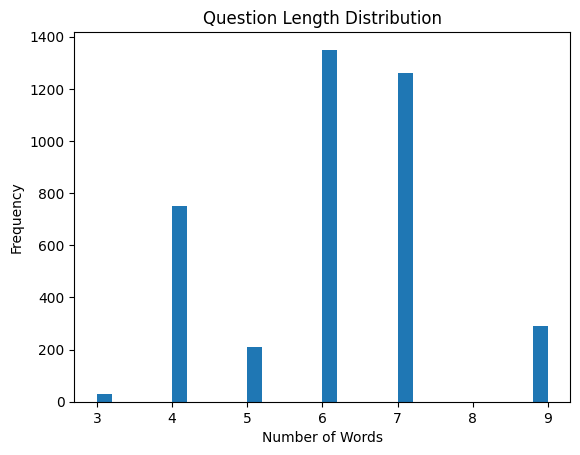

In [11]:
plt.hist(question_lengths, bins=30)
plt.title("Question Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [13]:
# Answer Length Distribution

all_answers = []

for df in qa_data:
    all_answers.extend(df["answer"].tolist())

answer_lengths = [len(a.split()) for a in all_answers]

print("Average answer length:", sum(answer_lengths)/len(answer_lengths))

Average answer length: 4.9406169665809765


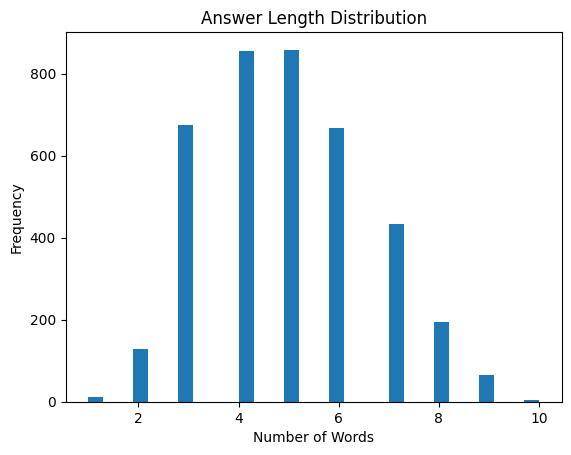

In [14]:
plt.hist(answer_lengths, bins=30)
plt.title("Answer Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [21]:
import arabic_reshaper
from bidi.algorithm import get_display

In [19]:
# Transcript Word Frequency Analysis
from collections import Counter

all_text = " ".join(transcripts)

tokens = all_text.split()

word_counts = Counter(tokens)

print(word_counts.most_common(20))

[('في', 1995), ('يا', 1806), ('عزيزي،', 1313), ('من', 1292), ('اللي', 1276), ('ما', 1135), ('إن', 916), ('على', 885), ('كان', 619), ('دا', 472), ('مش', 469), ('هو', 429), ('كل', 413), ('عشان', 365), ('زي', 341), ('دي', 338), ('انت', 296), ('بس', 263), ('كانت', 261), ('كدا،', 250)]


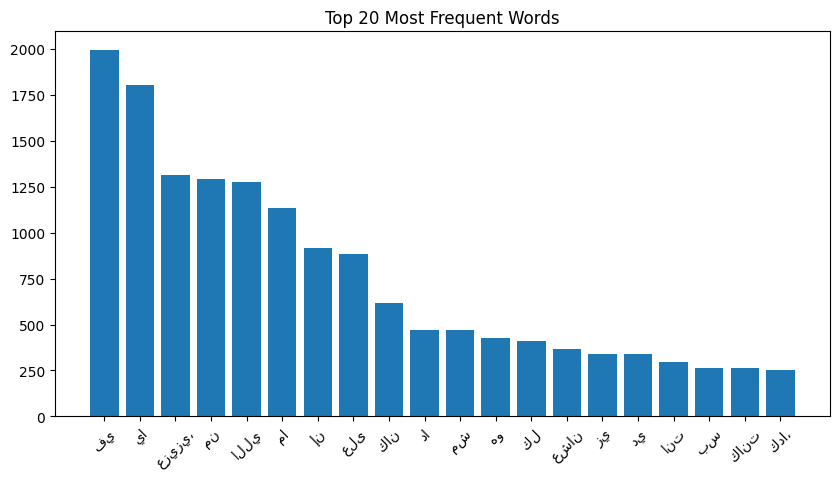

In [20]:
# Plotting Top Words
top_words = word_counts.most_common(20)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

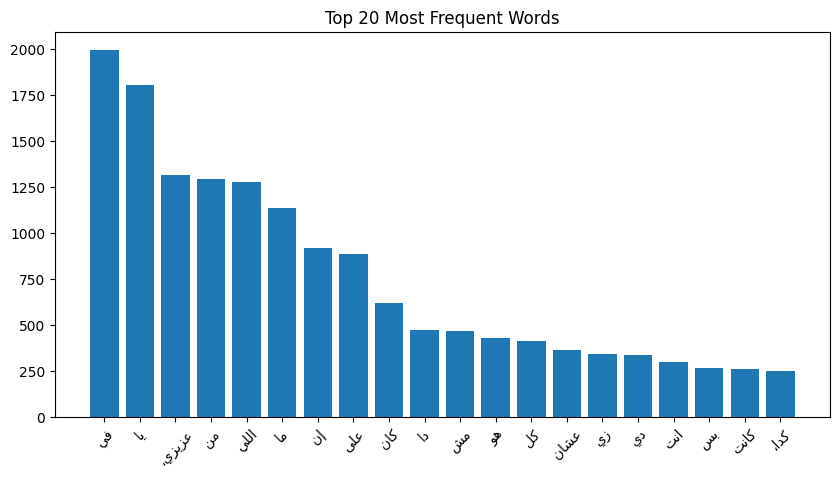

In [22]:
top_words = word_counts.most_common(20)

words = [get_display(arabic_reshaper.reshape(w[0])) for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

In [48]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import bigrams
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\malak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

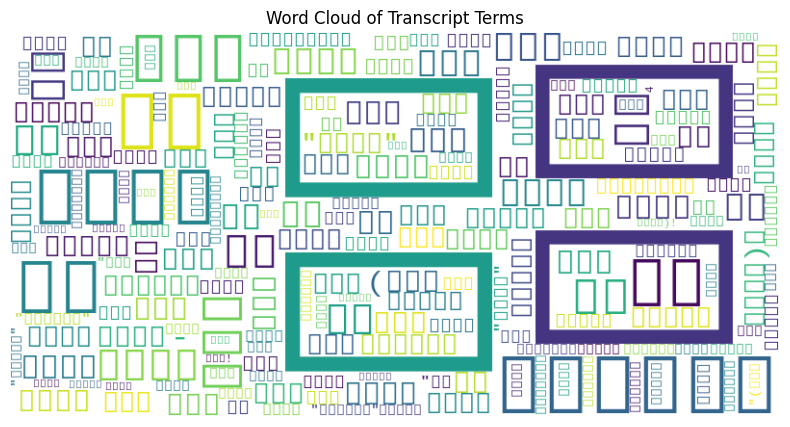

In [ ]:
# wordcloud = WordCloud(
#     width=800,
#     height=400,
#     background_color="white"
# ).generate_from_frequencies(word_counts)

# plt.figure(figsize=(10,5))
# plt.imshow(wordcloud, interpolation="bilinear")
# plt.axis("off")
# plt.title("Word Cloud of Transcript Terms")
# plt.show()


In [23]:
# Transcript Length Distribution
transcript_lengths = [len(t.split()) for t in transcripts]

print("Average transcript length:", sum(transcript_lengths)/len(transcript_lengths))

Average transcript length: 6875.2307692307695


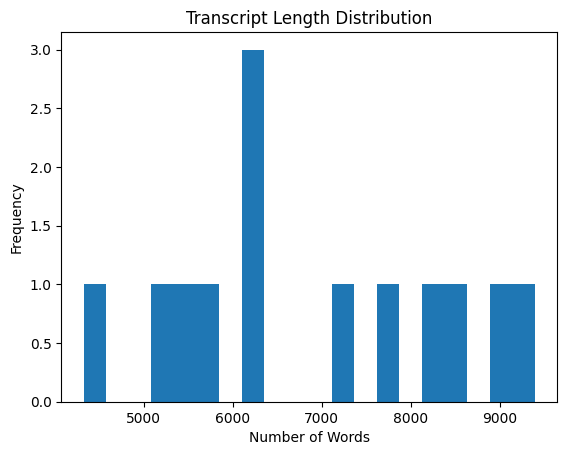

In [24]:
plt.hist(transcript_lengths, bins=20)
plt.title("Transcript Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [28]:
# Code-Switching Detection
import re

english_words = []

for t in transcripts:
    words = re.findall(r'[A-Za-z]+', t)
    english_words.extend(words)

print("Example English words detected:")
print(set(english_words))

Example English words detected:
{'Interferometer', 'Frame', 'scan', 'Satellites', 'Consciousness', 'Moscow', 'VR', 'free', 'follow', 'Horizon', 'pocket', 'Universe', 'Chonmage', 'Loss', 'Season', 'Actually', 'Depression', 'Embassy', 'GPS', 'Commitment', 'Fiction', 'Rasputin', 'paranoid', 'Angle', 'welcome', 'universe', 'Father', 'Assassins', 'Fundamental', 'others', 'Oh', 'beginning', 'Shell', 'kids', 'Picture', 'Shots', 'Entrop', 'Wow', 'Damselfish', 'update', 'Prophet', 'Terrible', 'Happens', 'Nonlinear', 'Unification', 'APG', 'Castle', 'At', 'Code', 'As', 'Plain', 'Octopus', 'Tinder', 'Crunch', 'Objective', 'Ego', 'sled', 'Jet', 'Wrist', 'software', 'Consortium', 'Recognition', 'H', 'liberty', 'makeup', 'Vs', 'entertainer', 'Tasking', 'Package', 'and', 'just', 'VBB', 'Kinetic', 'Agent', 'Level', 'Achilles', 'Robot', 'to', 'have', 'somewhere', 'at', 'the', 'Initiative', 'Zero', 'Be', 'Game', 'Film', 'Voice', 'Sh', 'Aquarium', 'Americans', 'Worlds', 'Suckers', 'What', 'Hearst', 'Seafo

In [33]:
import re
from collections import Counter

english_words = []

for t in transcripts:
    # words = re.findall(r'[A-Za-z]+', t)
    words = re.findall(r'[A-Za-z]{3,}', t)
    english_words.extend(words)

print("Total English tokens:", len(english_words))

unique_english = set(english_words)
print("Unique English words:", len(unique_english))

english_counts = Counter(english_words)

print("Most common English words:")
print(english_counts.most_common(10))

Total English tokens: 971
Unique English words: 621
Most common English words:
[('The', 21), ('cult', 20), ('Kane', 15), ('Citizen', 14), ('Streltsy', 13), ('Actually', 12), ('Seppuku', 10), ('actually', 9), ('FBI', 9), ('Entropy', 8)]


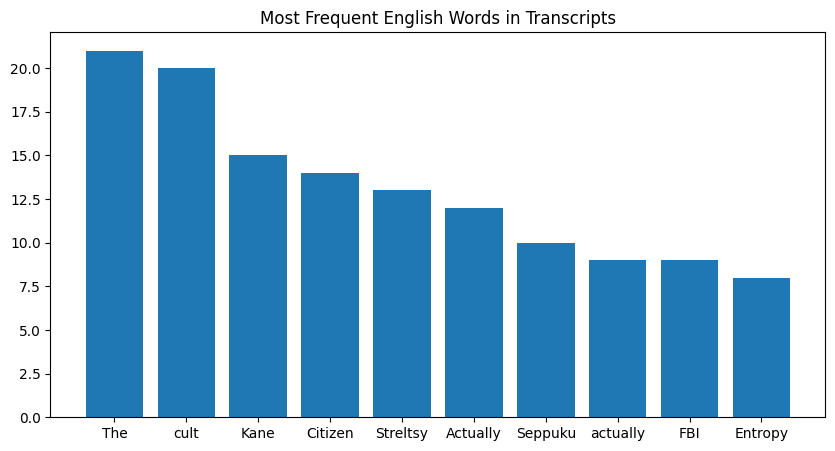

In [34]:
top_eng = english_counts.most_common(10)

words = [w[0] for w in top_eng]
counts = [w[1] for w in top_eng]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Most Frequent English Words in Transcripts")
plt.show()

In [42]:
# TF-IDF Keyword Analysis
from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer()

from sklearn.feature_extraction.text import TfidfVectorizer

arabic_stopwords = [
"في","من","على","ما","يا","اللي","هو","هي","كان","كانت","دا","دي","مش"
]

vectorizer = TfidfVectorizer(stop_words=arabic_stopwords)

tfidf_matrix = vectorizer.fit_transform(transcripts)

feature_names = vectorizer.get_feature_names_out()

print("Number of documents:", tfidf_matrix.shape[0])
print("Vocabulary size:", tfidf_matrix.shape[1])

Number of documents: 13
Vocabulary size: 22176


In [43]:
import numpy as np

first_doc = tfidf_matrix[0].toarray()[0]

top_indices = np.argsort(first_doc)[-10:]

for i in top_indices:
    print(feature_names[i])

كدا
الطيار
الطيارات
الرادار
35
إن
طيارة
الطيارة
الـf
عزيزي


This prints top TF-IDF words for transcript 1.

These should represent the topic of the episode.

In [44]:
import numpy as np

doc_index = 0

doc_vector = tfidf_matrix[doc_index].toarray()[0]

top_indices = np.argsort(doc_vector)[-10:]

for i in top_indices:
    print(feature_names[i])

كدا
الطيار
الطيارات
الرادار
35
إن
طيارة
الطيارة
الـf
عزيزي


In [45]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import bigrams
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\malak\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True